In [1]:
from PipingSystem import PipingSystem
from Elements.Coil import Coil
from Elements.Singularities import SingularityLoss
from Elements.Tube import Tube
import CoolProp.CoolProp as cp
import numpy as np
from Pumps.Lauda import LaudaPumpFit
import matplotlib.pyplot as plt
from scipy.optimize import newton
import Experiments.NaturalConvection as nc
import ht 

8.26


Definimos serpentin

In [2]:
coil = Coil(d_in = 5.15e-3, d_out=6.35e-3, lenght=0.787687, orientation=-90, material="copper", vueltas = 5, pitch=12e-3)

Definimos el sistema

In [3]:
fluxsys = PipingSystem()
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(1.05+1.7)) 
fluxsys.add_coil(coil) # Serpentin
fluxsys.add_singularity_loss(SingularityLoss(1.7)) 
fluxsys.add_tube(Tube(d_in = 5.15e-3, d_out = 6.35e-3, lenght=0.1, orientation=0, material="copper")) # Primera manguera del lauda
fluxsys.add_singularity_loss(SingularityLoss(0.5)) 
fluxsys.add_tube(Tube(d_in = 12.7e-3, d_out = 13.5e-3, lenght=1.5, orientation=0, material="Plastic")) # Segunda manguera del lauda
fluxsys.conect() # Conectar

Definimos el Fluido

In [4]:
tl = 273.15 + 5
pl = 101325        
mul = 0.0026 # Pa*s
rhol = 988.4 # kg/m3
cpl = 4300 # J /(kg K)
kl = 0.51 # W/(m K)
prl = mul*cpl/kl


print(prl, kl)

21.92156862745098 0.51


Buscamos donde cruza la curva del sistema con la curva de la bomba

In [7]:
Q_op, Q_op_lmin, dp_op, dh_op = fluxsys.cross_system_pump(rhol,mul, LaudaPumpFit.Pa4m3s, 3.25e-5,verbose=True);


═════════════════════════════════════════════
        UNTO DE OPERACIÓN DEL SISTEMA        
═════════════════════════════════════════════
 Caudal volumétrico :    1.791 L/min
 Caudal volumétrico      : 2.98e-05 m³/s
 Presión de cruce   :  18105.2 Pa
 Pérdida de altura  :    1.867 m.c.a.
═════════════════════════════════════════════



In [8]:
def ap_from_T(T):
    return (2.5179e-7) * (T**2) + (-1.3127e-4) * T + (1.7210e-2)
def nu_from_T(T):
    return  1.3686547347844438e-06*np.exp(1913.7989961446747/T)

In [9]:
m_dot = Q_op*rhol
# coil = TuClaseSerpentin(...)
# cpl, kl, mul, prl, rhol = ... (Propiedades del fluido interno)
def calcular_salida_y_pared(twater, tin, twall_guess=283.15, gas = False, resistencia_burbujas = False):
    """
    Simulador predictivo real usando el método epsilon-NTU global.
    Garantiza que el calor transferido sea idéntico al cambio de entalpía del fluido.
    """
    tol = 0.05
    relax = 0.2  # Un poco más alto para acelerar, ya que el método es más estable
    max_iter = 5000
    
    twall_out = twall_guess 
    tout = tin + 1.0 
    q = 0
    
    for i in range(max_iter):
        
        # --- 1) LADO INTERNO (Fluido) ---
        Re = (4 * m_dot) / (np.pi * coil.d_in * mul)
        coil.set_hidraulica(Q_op, rhol, mul)
        hi = coil.get_ht(prl, prl, mul, mul, kl)
        
        R_int = 1 / (hi * coil.area_in)
        
        # --- 2) PARED (Conducción) ---
        R_cond = (np.log(coil.d_out / coil.d_in) / (2 * np.pi * coil.conductivity * coil.lenght) if not resistencia_burbujas 
                  else 0.5)  # Agregar resistencia adicional para modelar burbujas adheridas a la pared (si se desea)
        
        # --- 3) LADO EXTERNO (Baño y Rayleigh) ---
        tfo = (twater + twall_out) / 2
        if np.isnan(tfo) or tfo < 273.16: tfo = 273.20
            
        beta = cp.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', tfo, 'P', 101325, "water") if not gas else ap_from_T(tfo)
        prandtl = (
                cp.PropsSI('Prandtl', 'T', tfo, 'P', 101325, "water") 
                if not gas 
                else nu_from_T(tfo) * cp.PropsSI('C', 'T', tfo, 'P', 101325, "water") / cp.PropsSI('conductivity', 'T', tfo, 'P', 101325, "water")
                )
        nu_o = cp.PropsSI('V', 'T', tfo, 'P', 101325, "water") / cp.PropsSI('D', 'T', tfo, 'P', 101325, "water") if not gas else nu_from_T(tfo)/cp.PropsSI('D', 'T', tfo, 'P', 101325, "water")
        k_bath = cp.PropsSI('conductivity', 'T', tfo, 'P', 101325, "water")
        
        delta_T = abs(twater - twall_out)
        if delta_T < 0.01: delta_T = 0.01
            
        gr = (9.81 * beta * delta_T * (coil.d_out**3)) / (nu_o**2)
        
        Nuo = ht.conv_free_immersed.Nu_coil_Xin_Ebadian(Pr=prandtl, Gr=gr, horizontal=True)
        ho = (Nuo * k_bath) / coil.d_out
        
        R_ext = 1 / (ho * coil.area_out)
        
        # --- 4) BALANCE TÉRMICO GLOBAL (MÉTODO EPSILON-NTU) ---
        # 1/UA es la suma de las resistencias reales de la serie térmica
        UA = 1 / (R_int + R_cond + R_ext)
        
        # C_min en este caso es simplemente el fluido interno (el baño exterior es infinito/estancado)
        C_min = m_dot * cpl
        
        NTU = UA / C_min
        epsilon = 1 - np.exp(-NTU)  # Perfil para fluido con temperatura externa constante (banco/tanque)
        
        # Calor máximo posible vs Calor real
        q_max = C_min * (twater - tin)
        q_new = epsilon * q_max
        
        # --- 5) RECALCULAR TEMPERATURAS (Consistentes) ---
        # La temperatura de pared externa depende estrictamente del calor que logra salir al baño
        twall_out_new = twater - q_new * R_ext
        
        # La temperatura de salida es consecuencia directa de la energía ganada
        tout_new = tin + q_new / C_min
        
        # --- 6) CONVERGENCIA ---
        if abs(twall_out_new - twall_out) < tol:
            twall_out = twall_out_new
            tout = tout_new
            q = q_new
            break
            
        # Aplicamos relajación sobre la temperatura de la pared para el cálculo de propiedades del fluido exterior
        twall_out = twall_out + relax * (twall_out_new - twall_out)
        
    return tout, twall_out, q


In [10]:
import numpy as np
import CoolProp.CoolProp as cp

# =====================================================================
# 1. CONFIGURACIÓN GENERAL Y VECTORES DE TIEMPO
# =====================================================================
M_tanque = 0.350 * 0.9985  # Masa de agua en el baño (kg)
dt = 0.5                  # Paso de tiempo en segundos
tiempo_total = 6 * 60      # 6 minutos en segundos (según tu variable tiempo_total)

t_bath_inicial = 273.15 + 16  # 16 °C en Kelvin
tin = 273.15 + 5              # 5 °C en Kelvin

# Diccionario para almacenar los resultados de ambos escenarios
resultados = {}

# =====================================================================
# 2. EJECUCIÓN DE LAS SIMULACIONES
# =====================================================================
for modo_gas in [False, True]:
    etiqueta = "Gas (True)" if modo_gas else "Líquido (False)"
    print(f"Iniciando simulación transitoria usando: {etiqueta}...")
    
    # Reiniciar variables para cada simulación
    t_bath_actual = t_bath_inicial
    twall_out = 283.15  # Guess inicial genérico
    
    # Historiales locales para este escenario
    historial_tiempo = []
    historial_t_bath = []
    historial_tout = []
    historial_q = []
    historial_twall = []
    
    for t in np.arange(0, tiempo_total, dt):
        # Llamado a tu función respetando el twall_guess iterativo y el parámetro gas
        tout, twall_out, q = calcular_salida_y_pared(
            t_bath_actual, 
            tin, 
            twall_guess=twall_out, 
            gas=modo_gas
        )
        
        # Guardar datos en escala Celsius / Watts
        historial_tiempo.append(t)
        historial_t_bath.append(t_bath_actual - 273.15)
        historial_tout.append(tout - 273.15)
        historial_q.append(q)
        historial_twall.append(twall_out - 273.15)
        
        # 3. Cambio de temperatura del baño (Balance de energía del tanque)
        # Nota: Usamos 'Cp' en mayúsculas/minúsculas estándar para CoolProp
        cp_tanque_actual = cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water")
        dT_bath = (-q * dt) / (M_tanque * cp_tanque_actual)
        
        # 4. Actualizar temperatura del baño para el siguiente paso temporal
        t_bath_actual += dT_bath
        
    # Guardar todo el set de listas en nuestro diccionario de resultados
    resultados[modo_gas] = {
        'tiempo': historial_tiempo,
        't_bath': historial_t_bath,
        'tout': historial_tout,
        'q': historial_q,
        'twall': historial_twall
    }
    print(f"--> Simulación con {etiqueta} finalizada con éxito.")

print("\n--- ¡TODOS LOS CÁLCULOS COMPLETADOS! ---")

Iniciando simulación transitoria usando: Líquido (False)...
--> Simulación con Líquido (False) finalizada con éxito.
Iniciando simulación transitoria usando: Gas (True)...
--> Simulación con Gas (True) finalizada con éxito.

--- ¡TODOS LOS CÁLCULOS COMPLETADOS! ---


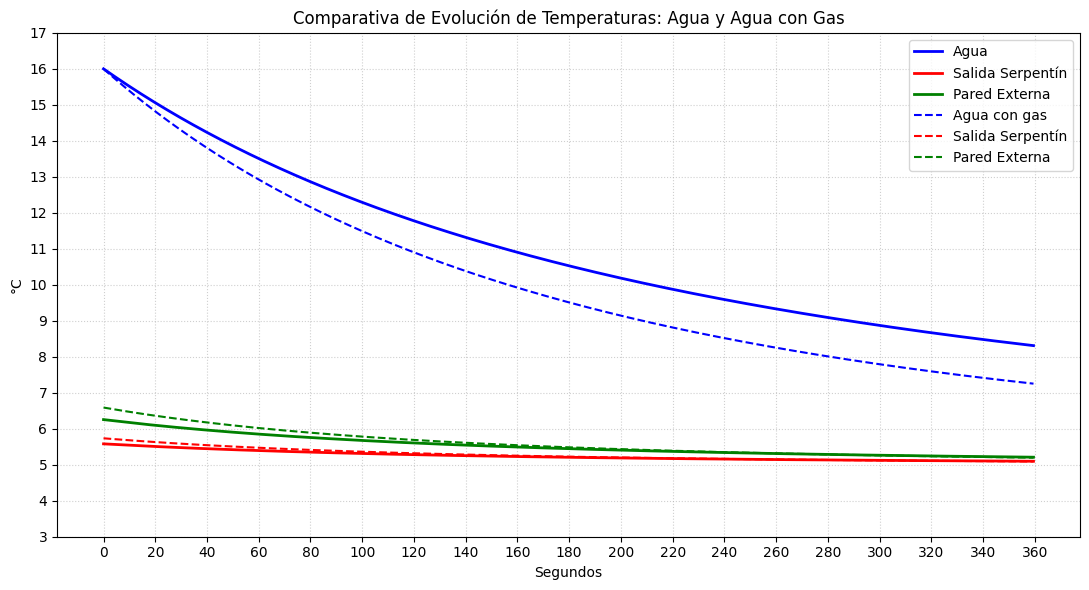

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Extraemos el tiempo
tiempo = np.array(resultados[False]['tiempo'])

# Configuramos una figura de un solo panel
plt.figure(figsize=(11, 6))

# ---------------------------------------------------------------------
# EVOLUCIÓN DE TEMPERATURAS (LÍQUIDO VS GAS)
# ---------------------------------------------------------------------

# Caso 1: Líquido (gas = False) -> Líneas continuas
plt.plot(tiempo, resultados[False]['t_bath'], label="Agua", color='blue', linewidth=2)
plt.plot(tiempo, resultados[False]['tout'], label="Salida Serpentín", color='red', linewidth=2)
plt.plot(tiempo, resultados[False]['twall'], label="Pared Externa", color='green', linewidth=2)

# Caso 2: Gas (gas = True) -> Líneas segmentadas
plt.plot(tiempo, resultados[True]['t_bath'], label="Agua con gas", color='blue', linestyle='--', linewidth=1.5)
plt.plot(tiempo, resultados[True]['tout'], label="Salida Serpentín", color='red', linestyle='--', linewidth=1.5)
plt.plot(tiempo, resultados[True]['twall'], label="Pared Externa", color='green', linestyle='--', linewidth=1.5)

# Configuración estricta de ejes y formato
plt.yticks(np.arange(3, 18, 1))
plt.xticks(np.arange(0, 370, 20))
plt.xlabel("Segundos")
plt.ylabel("°C")
plt.title("Comparativa de Evolución de Temperaturas: Agua y Agua con Gas")

# Leyenda al costado para no obstruir las curvas del transitorio
plt.legend(loc="best")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

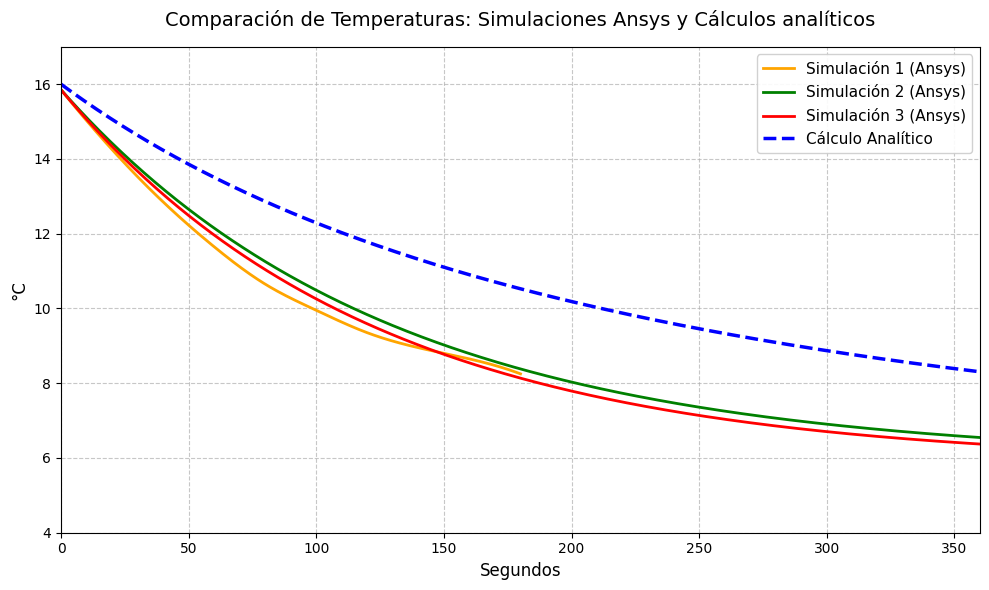

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

puntos_clave_sim1_K = np.array([
    [0, 289.0], [20, 287.4], [40, 286.0], [60, 284.8],
    [80, 283.8], [100, 283.1], [120, 282.5], [140, 282.1],
    [160, 281.8], [180, 281.4]
])
t_sim1 = np.linspace(0, 180, 500)
# Interpolación en Celsius directamente
f_interpolacion = interp1d(puntos_clave_sim1_K[:, 0], puntos_clave_sim1_K[:, 1] - 273.15, kind='cubic')
temperatura_sim1_C = f_interpolacion(t_sim1)



t_sim23 = np.linspace(0, 360, 500)

# Simulación 2 Ansys (Convertida a Celsius)
temperatura_sim2_C = (9.9 * np.exp(-0.0078 * t_sim23) + 279.1) - 273.15

# Simulación 3 Ansys (Convertida a Celsius)
temperatura_sim3_C = (10.0 * np.exp(-0.0082 * t_sim23) + 279.0) - 273.15

# Curva Determinista extraída de tu gráfico en Python (Ya está en Celsius)
# Parte de 16°C y baja asintóticamente
temperatura_determinista = 9.22 * np.exp(-0.00519 * t_sim23) + 6.78



fig, ax = plt.subplots(figsize=(10, 6))

# Graficar las 3 simulaciones de Ansys
ax.plot(t_sim1, temperatura_sim1_C, color='orange', linewidth=2.0, label='Simulación 1 (Ansys)')
ax.plot(t_sim23, temperatura_sim2_C, color='green', linewidth=2.0, label='Simulación 2 (Ansys)')
ax.plot(t_sim23, temperatura_sim3_C, color='red', linewidth=2.0, label='Simulación 3 (Ansys)')


#ax.plot(t_sim23, temperatura_determinista, color='blue', linewidth=2.5, label='Cálculo Analítico', linestyle='--')
plt.plot(tiempo, resultados[False]['t_bath'], color='blue', linewidth=2.5, label='Cálculo Analítico', linestyle='--')


ax.set_title("Comparación de Temperaturas: Simulaciones Ansys y Cálculos analíticos", fontsize=14, pad=15)
ax.set_xlabel("Segundos", fontsize=12)
ax.set_ylabel("°C", fontsize=12)


ax.set_xlim(0, 360)
ax.set_ylim(4, 17) 


ax.grid(True, linestyle='--', alpha=0.7)


ax.legend(fontsize=11, loc='upper right', framealpha=0.9)

plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [14]:
import numpy as np
import CoolProp.CoolProp as cp

# =====================================================================
# 1. CONFIGURACIÓN GENERAL Y VECTORES DE TIEMPO
# =====================================================================
M_tanque = 0.350 * 0.9985  # Masa de agua en el baño (kg)
dt = 0.5                  # Paso de tiempo en segundos
tiempo_total = 6 * 60      # 6 minutos en segundos

tin = 273.15 + 5           # 5 °C en Kelvin
modo_gas = False           # Fijo en modo líquido (False) según la solicitud

# Diccionario para almacenar los resultados para cada temperatura inicial
resultados_curvas = {}

# Generamos un array con las temperaturas desde 25 hasta 13 (incluido) en pasos de -1
temperaturas_iniciales = np.arange(25, 12, -1) 

# =====================================================================
# 2. EJECUCIÓN DE LAS SIMULACIONES
# =====================================================================
print("Iniciando simulaciones transitorias (modo gas = False)...")

for T_ini_C in temperaturas_iniciales:
    # Reiniciar variables para la simulación actual
    t_bath_inicial = 273.15 + T_ini_C
    t_bath_actual = t_bath_inicial
    twall_out = 283.15  # Guess inicial genérico
    
    # Historiales locales para este escenario
    historial_tiempo = []
    historial_t_bath = []
    historial_tout = []
    historial_q = []
    historial_twall = []
    
    for t in np.arange(0, tiempo_total, dt):
        # Llamado a tu función (asegúrate de que esté definida en una celda previa)
        tout, twall_out, q = calcular_salida_y_pared(
            t_bath_actual, 
            tin, 
            twall_guess=twall_out, 
            gas=modo_gas
        )
        
        # Guardar datos en escala Celsius / Watts
        historial_tiempo.append(t)
        historial_t_bath.append(t_bath_actual - 273.15)
        historial_tout.append(tout - 273.15)
        historial_q.append(q)
        historial_twall.append(twall_out - 273.15)
        
        # 3. Cambio de temperatura del baño (Balance de energía del tanque)
        cp_tanque_actual = cp.PropsSI('C', 'T', t_bath_actual, 'P', 101325, "water")
        dT_bath = (-q * dt) / (M_tanque * cp_tanque_actual)
        
        # 4. Actualizar temperatura del baño para el siguiente paso temporal
        t_bath_actual += dT_bath
        
    # Guardar todo el set de listas en nuestro diccionario indexado por la Temp. Inicial
    resultados_curvas[T_ini_C] = {
        'tiempo': historial_tiempo,
        't_bath': historial_t_bath,
        'tout': historial_tout,
        'q': historial_q,
        'twall': historial_twall
    }
    print(f"--> Simulación desde {T_ini_C} °C finalizada con éxito.")

print("\n--- ¡TODOS LOS CÁLCULOS COMPLETADOS! ---")

Iniciando simulaciones transitorias (modo gas = False)...
--> Simulación desde 25 °C finalizada con éxito.
--> Simulación desde 24 °C finalizada con éxito.
--> Simulación desde 23 °C finalizada con éxito.
--> Simulación desde 22 °C finalizada con éxito.
--> Simulación desde 21 °C finalizada con éxito.
--> Simulación desde 20 °C finalizada con éxito.
--> Simulación desde 19 °C finalizada con éxito.
--> Simulación desde 18 °C finalizada con éxito.
--> Simulación desde 17 °C finalizada con éxito.
--> Simulación desde 16 °C finalizada con éxito.
--> Simulación desde 15 °C finalizada con éxito.
--> Simulación desde 14 °C finalizada con éxito.
--> Simulación desde 13 °C finalizada con éxito.

--- ¡TODOS LOS CÁLCULOS COMPLETADOS! ---


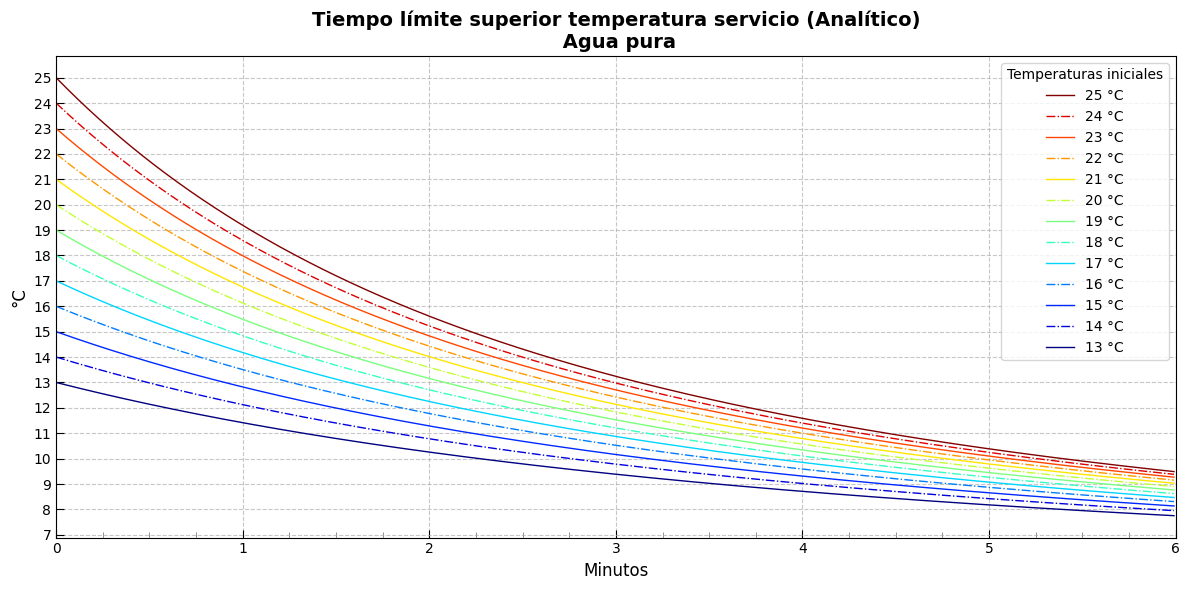

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# =====================================================================
# 3. GRAFICAR LOS RESULTADOS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6)) 

colores = plt.cm.jet_r(np.linspace(0, 1, len(temperaturas_iniciales)))

for i, T_ini_C in enumerate(temperaturas_iniciales):
    if i%2 == 0:  
        datos = resultados_curvas[T_ini_C]
        
        # Volvemos a convertir el tiempo a minutos
        tiempo_minutos = np.array(datos['tiempo']) / 60
        t_bath_historico = datos['t_bath']
        
        ax.plot(tiempo_minutos, t_bath_historico, label=f'{T_ini_C} °C', color=colores[i], linewidth=1)
    else:
        datos = resultados_curvas[T_ini_C]
        
        # Volvemos a convertir el tiempo a minutos
        tiempo_minutos = np.array(datos['tiempo']) / 60
        t_bath_historico = datos['t_bath']
        
        ax.plot(tiempo_minutos, t_bath_historico, label=f'{T_ini_C} °C', color=colores[i], linewidth=1, linestyle='-.')

# Configuraciones de títulos y etiquetas
ax.set_title('Tiempo límite superior temperatura servicio (Analítico)\n Agua pura', fontsize=14, fontweight='bold')
ax.set_xlabel('Minutos', fontsize=12)
ax.set_ylabel('°C', fontsize=12)

# =====================================================================
# AJUSTE DE EJES (Límites, Ticks Principales y Secundarios)
# =====================================================================
# 1. Límites estrictos: De 0 a 6 minutos
ax.set_xlim(0, 6)

# 2. Eje Y: Marcas principales de 1 en 1 grado
ax.yaxis.set_major_locator(MultipleLocator(1))

# 3. Eje X: 
#    - Marcas principales (con número) cada 1 minuto
ax.xaxis.set_major_locator(MultipleLocator(1))
#    - Marcas menores (ticks pequeños) cada 0.25 minutos (15 segundos)
ax.xaxis.set_minor_locator(MultipleLocator(0.25))

# Hacemos que los ticks menores sean un poco más visibles hacia adentro o afuera
ax.tick_params(which='minor', length=4, color='gray', direction='in')
ax.tick_params(which='major', length=6, direction='in')

# Mostramos la cuadrícula solo para las marcas principales
ax.grid(which='major', linestyle='--', alpha=0.7)

# Si quieres que también haya líneas de cuadrícula en los 15s, descomenta esta línea:
# ax.grid(which='minor', linestyle=':', alpha=0.4)

# Colocamos la leyenda
ax.legend(loc='upper right', title="Temperaturas iniciales")

plt.tight_layout()
plt.show()